# A two-line model for chunk read cost

Let $M$ be a set of selected weight rows, $\mathcal C(M)$ its maximal contiguous runs, and $q$ the row length in KiB. A table of chunk costs gives the additive estimate

$$L_{\mathrm{table}}(M)=\sum_{C\in\mathcal C(M)}T(q|C|).$$

We approximate $T$ by two continuous lines, with constant cost per KiB beyond a fitted boundary. We compare that boundary with two summaries of the measured curve and evaluate the approximation on held-out measurement blocks.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls

CSV_PATH = Path("block_estimates.csv")

## 1. Read the measured curve

For chunk length $z$ KiB, the profiler's batch throughput $\widehat\beta_b(z)$ in MiB/s gives the amortized cost

$$\widehat T_b(z)=\frac{1000z}{1024\widehat\beta_b(z)}\quad\mathrm{ms/chunk}.$$

Read `block_estimates.csv` from this notebook's directory. Its measured chunk lengths form the grid $\mathcal G$. The median over all seven blocks defines $T(z)$; blocks 0–3 define $T_{\mathrm{train}}$ and blocks 4–6 define $T_{\mathrm{test}}$.

To regenerate the CSV, run [01_01_measure_chunk_latency.ipynb](01_01_measure_chunk_latency.ipynb).

In [2]:
data = pd.read_csv(CSV_PATH)
wide = data.pivot(index="size_kib", columns="block", values="latency_ms")
wide = wide.sort_index().sort_index(axis=1)
z, samples = wide.index.to_numpy(float), wide.to_numpy(float)
T = np.median(samples, axis=1)
T_train = np.median(samples[:, :4], axis=1)
T_test = np.median(samples[:, 4:], axis=1)

## 2. Summarize the measured curve

The cost per KiB and its minimizing length are

$$\rho(z)=\frac{T(z)}z,\qquad z_{\rm eff}\in\arg\min_{z\in\mathcal G}\rho(z).$$

Since $\beta(z)=1000/(1024\rho(z))$, this also locates peak throughput. A second summary is the first size reaching 99% of the peak training throughput after a centered three-point median:

$$z_{99}=\min\left\{z\in\mathcal G:\widetilde\beta_{\mathrm{train}}(z)
\ge0.99\max_{u\in\mathcal G}\widetilde\beta_{\mathrm{train}}(u)\right\}.$$

Here smoothing uses adjacent grid points, with the available neighbors at each endpoint. A first crossing allows later sizes to fall below the threshold. We keep the full grid for fitting.

In [3]:
rho = T / z
z_eff = z[np.argmin(rho)]
B = 1000 * z / (1024 * T_train)
B_smooth = pd.Series(B).rolling(3, center=True, min_periods=1).median().to_numpy()
z_99 = z[np.flatnonzero(B_smooth >= .99 * B_smooth.max())[0]]

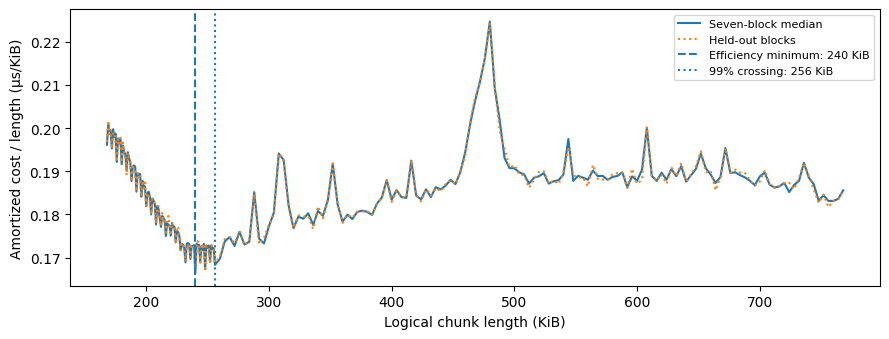

In [4]:
zoom = z >= 0.7 * min(z_eff, z_99)
plt.figure(figsize=(9, 3.5))
plt.plot(z[zoom], 1000 * rho[zoom], label="Seven-block median")
plt.plot(z[zoom], 1000 * T_test[zoom] / z[zoom], ":", label="Held-out blocks")
plt.axvline(z_eff, ls="--", label=f"Efficiency minimum: {z_eff:g} KiB")
plt.axvline(z_99, ls=":", label=f"99% crossing: {z_99:g} KiB")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Amortized cost / length (µs/KiB)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Fit the models

Consider the continuous family

$$T_{\rm 2L}(z;z_0)=c_1z+\delta\max(z_0,z)
=\begin{cases}\delta z_0+c_1z,&z\le z_0,\\(c_1+\delta)z,&z>z_0,\end{cases}
\qquad c_1,\delta\ge0.$$

The short-line intercept is $\delta z_0$. Beyond $z_0$, cost per KiB is fixed at $c_1+\delta$. For each candidate boundary, nonnegative least squares fits the coefficients to $T_{\mathrm{train}}$. The free fit chooses

$$z_{\rm 2L}\in\arg\min_{z_0\in\mathcal G^\circ}\min_{c_1,\delta\ge0}
\frac1{|\mathcal G|}\sum_{z\in\mathcal G}[T_{\mathrm{train}}(z)-T_{\rm 2L}(z;z_0)]^2,$$

where $\mathcal G^\circ$ excludes the first and last three grid sizes. Every measured size has equal weight, so the denser grid below 256 KiB contributes more observations.

For comparison, the hinge $T_H(z)=a+bz+d(z-z_H)_+$ allows a tail intercept $a-dz_H$, where $(x)_+=\max(x,0)$. Its coefficients are unconstrained and its boundary minimizes the same training loss. The affine baseline $T_A(z)=a+bz$ has no boundary.

In [5]:
def rmse(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))


def fit_two_line(boundary):
    X = np.column_stack((z, np.maximum(boundary, z)))
    coefficients = nnls(X, T_train)[0]
    return coefficients, X @ coefficients


two_line = {s: fit_two_line(s) for s in z}
z_candidates = z[3:-3]
E_two_line = np.array([rmse(T_train, two_line[s][1]) for s in z_candidates])
z_two_line = z_candidates[np.argmin(E_two_line)]
c1, delta = two_line[z_two_line][0]

In [6]:
def fit_hinge(boundary):
    X = np.column_stack((np.ones_like(z), z, np.maximum(z - boundary, 0)))
    coefficients = np.linalg.lstsq(X, T_train, rcond=None)[0]
    return coefficients, X @ coefficients


hinge = {s: fit_hinge(s) for s in z_candidates}
E_hinge = np.array([rmse(T_train, hinge[s][1]) for s in z_candidates])
z_hinge = z_candidates[np.argmin(E_hinge)]
ha, hb, hd = hinge[z_hinge][0]

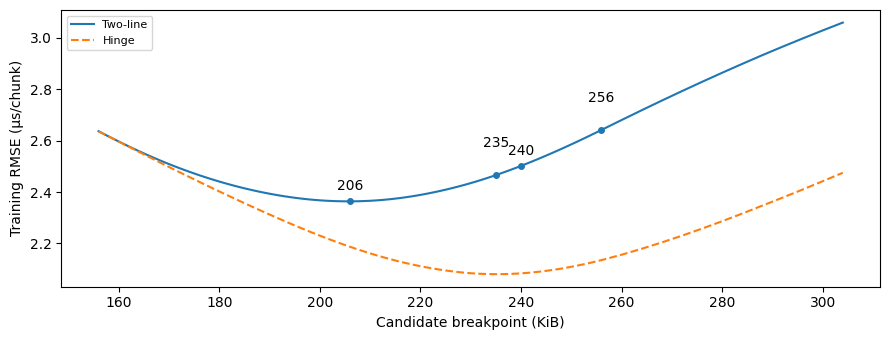

In [7]:
marked = sorted({z_eff, z_99, z_two_line, z_hinge})
local = (z_candidates >= min(marked) - 50) & (z_candidates <= max(marked) + 50)
plt.figure(figsize=(9, 3.5))
plt.plot(z_candidates[local], 1000 * E_two_line[local], label="Two-line")
plt.plot(z_candidates[local], 1000 * E_hinge[local], "--", label="Hinge")
for i, boundary in enumerate(marked):
    error = 1000 * rmse(T_train, two_line[boundary][1])
    plt.plot(boundary, error, "o", color="C0", ms=4)
    plt.annotate(f"{boundary:g}", (boundary, error), xytext=(0, 8 + 12 * (i % 2)),
                 textcoords="offset points", ha="center")
plt.xlabel("Candidate breakpoint (KiB)")
plt.ylabel("Training RMSE (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

We also fit the two-line coefficients with the boundary fixed at $z_{\rm eff}$, $z_{99}$ or $z_H$. The table shows each model's two segments in µs; predictions retain full precision in ms.

In [8]:
boundaries = {
    "Two-line (efficiency)": z_eff,
    "Two-line (99%)": z_99,
    "Two-line (hinge boundary)": z_hinge,
    "Two-line (free)": z_two_line,
}
predictions = {name: two_line[s][1] for name, s in boundaries.items()}
predictions["Hinge"] = hinge[z_hinge][1]
X_a = np.column_stack((np.ones_like(z), z))
aa, ab = np.linalg.lstsq(X_a, T_train, rcond=None)[0]
predictions["Affine"] = X_a @ [aa, ab]

In [9]:
parameter_rows = []
for name, boundary in boundaries.items():
    c, d = two_line[boundary][0]
    parameter_rows.append([name, boundary, 1000*d*boundary, 1000*c, 0., 1000*(c+d)])
parameter_rows += [["Hinge", z_hinge, 1000*ha, 1000*hb,
                   1000*(ha-hd*z_hinge), 1000*(hb+hd)],
                  ["Affine", np.nan, 1000*aa, 1000*ab, 1000*aa, 1000*ab]]
parameters = pd.DataFrame(parameter_rows, columns=["Model", "Boundary (KiB)",
    "Short intercept (µs)", "Short slope (µs/KiB)", "Tail intercept (µs)",
    "Tail slope (µs/KiB)"]).set_index("Model")
parameters.round(6)

,Boundary (KiB),Short intercept (µs),Short slope (µs/KiB),Tail intercept (µs),Tail slope (µs/KiB)
Model,,,,,
Two-line (efficiency),240.0,10.879302,0.141568,0.000000,0.186899
Two-line (99%),256.0,10.402829,0.146045,0.000000,0.186681
Two-line (hinge boundary),235.0,11.026668,0.140046,0.000000,0.186968
Two-line (free),206.0,11.851900,0.129853,0.000000,0.187387
Hinge,235.0,12.195007,0.125195,-4.504706,0.196257
Affine,NaN,5.889929,0.175610,5.889929,0.175610


## 4. Evaluate on held-out blocks

With the fitted curves frozen, evaluate

$$\mathrm{RMSE}=\sqrt{\frac1{|\mathcal G|}\sum_z[\widehat T(z)-T_{\mathrm{test}}(z)]^2},\qquad
\mathrm{MAPE}=\frac{100}{|\mathcal G|}\sum_z\frac{|\widehat T(z)-T_{\mathrm{test}}(z)|}{T_{\mathrm{test}}(z)}.$$

All coefficients, free boundaries and $z_{99}$ use training blocks only. The efficiency boundary $z_{\rm eff}$ uses all seven blocks, so its comparison is descriptive. These errors measure approximation to the held-out curve, not a change in SSD speed.

In [10]:
comparison = pd.DataFrame({name: {
    "Train RMSE (µs)": 1000 * rmse(T_train, prediction),
    "Holdout RMSE (µs)": 1000 * rmse(T_test, prediction),
    "Holdout MAPE (%)": 100 * np.mean(np.abs(prediction - T_test) / T_test),
} for name, prediction in predictions.items()}).T
comparison.index.name = "Model"
comparison.round(3)

,Train RMSE (µs),Holdout RMSE (µs),Holdout MAPE (%)
Model,,,
Two-line (efficiency),2.502,2.521,4.051
Two-line (99%),2.642,2.660,4.595
Two-line (hinge boundary),2.466,2.486,3.916
Two-line (free),2.364,2.383,3.499
Hinge,2.081,2.101,2.849
Affine,4.029,4.038,10.584


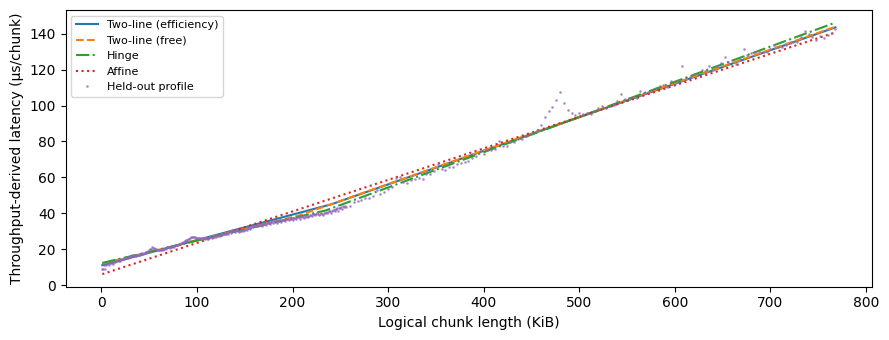

In [11]:
main_models = ["Two-line (efficiency)", "Two-line (free)", "Hinge"]
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models + ["Affine"], ["-", "--", "-.", ":"]):
    plt.plot(z, 1000 * predictions[name], style, label=name)
plt.plot(z, 1000 * T_test, ".", ms=2, alpha=.6, label="Held-out profile")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Throughput-derived latency (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

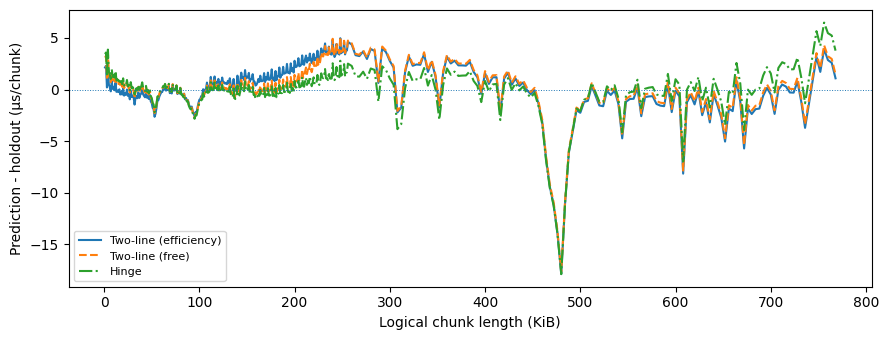

In [12]:
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models, ["-", "--", "-."]):
    plt.plot(z, 1000 * (predictions[name] - T_test), style, label=name)
plt.axhline(0, ls=":", lw=.7)
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Prediction - holdout (µs/chunk)")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

Residuals are prediction minus held-out cost; negative values indicate underestimation.

## 5. Derive the additive cost

The fitted boundary minimizes approximation error. The efficiency minimum and throughput crossing describe the measured curve; neither is imposed on the free fit.

The two-line form has a useful decomposition:

$$T_{\rm 2L}(z)=(c_1+\delta)z+\delta(z_{\rm 2L}-z)_+.$$

Substituting each run's length $q|C|$ gives

$$\boxed{L_{\rm 2L}(M)=(c_1+\delta)q|M|
+\delta\sum_{C\in\mathcal C(M)}(z_{\rm 2L}-q|C|)_+.}$$

For a fixed number of selected rows, the first term is constant. The second charges for runs shorter than the fitted boundary. This structure motivates the two-line approximation; the holdout errors quantify its fit to the measured curve. Complete-mask latency and extrapolation beyond the measured lengths require separate validation.

The final cell exports the free two-line coefficients, grid and source CSV hash to `latency_model.json`.

In [13]:
import hashlib, json

model = dict(
    format           = "vlm-in-flash-two-line-v1", 
    unit             = dict(length="KiB", time="ms"),
    csv_sha256       = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest(),
    fit_blocks       = wide.columns[:4].tolist(), 
    holdout_blocks   = wide.columns[4:].tolist(),
    s_kib            = float(z_two_line), 
    c1_ms_per_kib    = float(c1), 
    delta_ms_per_kib = float(delta),
    s_eff_kib        = float(z_eff), 
    s99_kib          = float(z_99), 
    s_hinge_kib      = float(z_hinge),
    measured_grid_kib = z.tolist(),
    fit               = "unweighted NNLS; free boundary on measured grid [3:-3]",
    acquisition_reference ="9023679ebfd1900fa2912c4098f51bfb9efa7bb8"
)

model_path = CSV_PATH.with_name("latency_model.json")
with model_path.open("w", encoding="utf-8") as f:
    json.dump(model, f, indent=2)
    f.write("\n")